In [6]:
!pip install kaggle wandb -Uq
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp "/content/drive/MyDrive/Colab Notebooks/kaggle_API_credentials/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d fer2013

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
replace fer2013/example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [9]:
from google.colab import userdata
import wandb
wandb.login(key=userdata.get('WANDB_API_KEY'))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ngval22 (ngval22-s) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
import itertools

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [11]:
df = pd.read_csv('./fer2013/train.csv')

train_val_df, test_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['emotion'])
train_df, val_df = train_test_split(train_val_df, test_size=0.111, random_state=42, stratify=train_val_df['emotion'])

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 22969, Val: 2869, Test: 2871


In [12]:
class_weights = compute_class_weight('balanced', classes=np.arange(7), y=train_df['emotion'].values)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print("Class weights:", class_weights)

Class weights: [1.026364   9.42898194 1.00100235 0.56848332 0.84919403 1.29337237
 0.82589623]


In [13]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        pixels = np.array(row['pixels'].split(' '), dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)  # fixed: no mode='L', inferred from 2D array
        if self.transform:
            image = self.transform(image)
        label = int(row['emotion'])
        return image, label

In [14]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # new: adds lighting variation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5077], std=[0.2550])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5077], std=[0.2550])
])

In [15]:
class MediumCNN(nn.Module):
    """
    Architecture 2 — Medium CNN.
    Changes from baseline:
    - 4 conv layers (was 2): more capacity to learn complex features
    - BatchNorm after every conv: stabilizes training, allows higher LR
    - Dropout(0.5) in classifier: regularization to combat overfitting
    - Doubled filters at each stage: 32->64->128->128
    - Global Average Pooling instead of Flatten: reduces parameters, less overfitting
    Motivation: baseline showed underfitting (train~=val~=50%).
    Need more capacity + regularization to push past that ceiling.
    """
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(MediumCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),       # 48x48 -> 24x24
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),       # 24x24 -> 12x12
            nn.Dropout2d(0.25),
        )

        # Global Average Pooling: 128 x 12 x 12 -> 128
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = MediumCNN(num_classes=7).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

MediumCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.25,

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [17]:
# Three configs to compare — vary only learning rate and dropout.
# 15 epochs each, pick the best, then full run.
# All logged to wandb for comparison.

configs_to_try = [
    {"lr": 1e-3,  "dropout": 0.3, "name": "arch2-probe-lr1e3-dr03"},
    {"lr": 3e-4,  "dropout": 0.5, "name": "arch2-probe-lr3e4-dr05"},
    {"lr": 1e-3,  "dropout": 0.5, "name": "arch2-probe-lr1e3-dr05"},
]

BATCH_SIZE = 64
train_loader = DataLoader(FERDataset(train_df, transform=train_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(FERDataset(val_df, transform=val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(FERDataset(test_df, transform=val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

probe_results = []

for cfg in configs_to_try:
    print(f"\nProbing: {cfg['name']}")

    probe_model = MediumCNN(num_classes=7, dropout_rate=cfg['dropout']).to(device)
    probe_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    probe_optimizer = optim.Adam(probe_model.parameters(), lr=cfg['lr'])

    run = wandb.init(
        project="facial-expression-recognition",
        name=cfg['name'],
        group="arch2-medium-probe",
        config={"architecture": "MediumCNN", "phase": "probe",
                "learning_rate": cfg['lr'], "dropout_rate": cfg['dropout'],
                "batch_size": BATCH_SIZE, "epochs": 15}
    )

    best_probe_val = 0.0
    for epoch in range(15):
        tl, ta = train_one_epoch(probe_model, train_loader, probe_optimizer, probe_criterion)
        vl, va = evaluate(probe_model, val_loader, probe_criterion)
        wandb.log({"epoch": epoch+1, "train_loss": tl, "train_acc": ta,
                   "val_loss": vl, "val_acc": va})
        if va > best_probe_val:
            best_probe_val = va
        print(f"  Epoch {epoch+1:02d}/15 | Train Acc: {ta:.4f} | Val Acc: {va:.4f}")

    wandb.summary['best_val_acc'] = best_probe_val
    wandb.finish()
    probe_results.append((best_probe_val, cfg))
    print(f"  Best val acc: {best_probe_val:.4f}")

probe_results.sort(reverse=True, key=lambda x: x[0])
best_val, best_cfg = probe_results[0]
print(f"\nBest config: lr={best_cfg['lr']}, dropout={best_cfg['dropout']} -> val_acc={best_val:.4f}")


Probing: arch2-probe-lr1e3-dr03


  Epoch 01/15 | Train Acc: 0.1738 | Val Acc: 0.1715
  Epoch 02/15 | Train Acc: 0.1905 | Val Acc: 0.2255
  Epoch 03/15 | Train Acc: 0.2157 | Val Acc: 0.2196
  Epoch 04/15 | Train Acc: 0.2207 | Val Acc: 0.2168
  Epoch 05/15 | Train Acc: 0.2357 | Val Acc: 0.2834
  Epoch 06/15 | Train Acc: 0.2547 | Val Acc: 0.2761
  Epoch 07/15 | Train Acc: 0.2590 | Val Acc: 0.3022
  Epoch 08/15 | Train Acc: 0.2537 | Val Acc: 0.2694
  Epoch 09/15 | Train Acc: 0.2507 | Val Acc: 0.3168
  Epoch 10/15 | Train Acc: 0.2669 | Val Acc: 0.3200
  Epoch 11/15 | Train Acc: 0.2681 | Val Acc: 0.2966
  Epoch 12/15 | Train Acc: 0.2742 | Val Acc: 0.2865
  Epoch 13/15 | Train Acc: 0.2809 | Val Acc: 0.2771
  Epoch 14/15 | Train Acc: 0.2905 | Val Acc: 0.3691
  Epoch 15/15 | Train Acc: 0.3078 | Val Acc: 0.2896


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▂▃▃▄▅▅▅▅▆▆▆▇▇█
train_loss,█▇▇▆▆▅▄▃▃▃▂▂▂▁▁
val_acc,▁▃▃▃▅▅▆▄▆▆▅▅▅█▅
val_loss,█▇▇▆▅▅▄▄▃▅▃▃▅▂▁
best_val_acc,0.36912
epoch,15
train_acc,0.30781
train_loss,1.72956
val_acc,0.28965
val_loss,1.69867


  Best val acc: 0.3691

Probing: arch2-probe-lr3e4-dr05


  Epoch 01/15 | Train Acc: 0.1736 | Val Acc: 0.2140
  Epoch 02/15 | Train Acc: 0.1889 | Val Acc: 0.1767
  Epoch 03/15 | Train Acc: 0.1930 | Val Acc: 0.1976
  Epoch 04/15 | Train Acc: 0.1944 | Val Acc: 0.2314
  Epoch 05/15 | Train Acc: 0.2050 | Val Acc: 0.1621
  Epoch 06/15 | Train Acc: 0.2013 | Val Acc: 0.2039
  Epoch 07/15 | Train Acc: 0.2103 | Val Acc: 0.2841
  Epoch 08/15 | Train Acc: 0.2396 | Val Acc: 0.3046
  Epoch 09/15 | Train Acc: 0.2399 | Val Acc: 0.2492
  Epoch 10/15 | Train Acc: 0.2495 | Val Acc: 0.2032
  Epoch 11/15 | Train Acc: 0.2604 | Val Acc: 0.2736
  Epoch 12/15 | Train Acc: 0.2471 | Val Acc: 0.3228
  Epoch 13/15 | Train Acc: 0.2738 | Val Acc: 0.2820
  Epoch 14/15 | Train Acc: 0.2706 | Val Acc: 0.3057
  Epoch 15/15 | Train Acc: 0.2660 | Val Acc: 0.3050


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▂▂▂▃▃▄▆▆▆▇▆██▇
train_loss,█▇▇▇▇▆▅▅▄▃▃▂▂▁▁
val_acc,▃▂▃▄▁▃▆▇▅▃▆█▆▇▇
val_loss,███▇█▇▅▄▄▃▂▂▂▁▁
best_val_acc,0.32276
epoch,15
train_acc,0.26597
train_loss,1.79397
val_acc,0.30498
val_loss,1.77784


  Best val acc: 0.3228

Probing: arch2-probe-lr1e3-dr05


  Epoch 01/15 | Train Acc: 0.1720 | Val Acc: 0.1628
  Epoch 02/15 | Train Acc: 0.1758 | Val Acc: 0.1067
  Epoch 03/15 | Train Acc: 0.1722 | Val Acc: 0.1670
  Epoch 04/15 | Train Acc: 0.1889 | Val Acc: 0.2297
  Epoch 05/15 | Train Acc: 0.2151 | Val Acc: 0.2670
  Epoch 06/15 | Train Acc: 0.2352 | Val Acc: 0.1621
  Epoch 07/15 | Train Acc: 0.2340 | Val Acc: 0.2938
  Epoch 08/15 | Train Acc: 0.2503 | Val Acc: 0.2043
  Epoch 09/15 | Train Acc: 0.2642 | Val Acc: 0.1502
  Epoch 10/15 | Train Acc: 0.2563 | Val Acc: 0.2747
  Epoch 11/15 | Train Acc: 0.2581 | Val Acc: 0.3116
  Epoch 12/15 | Train Acc: 0.2551 | Val Acc: 0.3238
  Epoch 13/15 | Train Acc: 0.2655 | Val Acc: 0.1910
  Epoch 14/15 | Train Acc: 0.2574 | Val Acc: 0.2862
  Epoch 15/15 | Train Acc: 0.2591 | Val Acc: 0.2241


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▁▁▂▄▆▆▇█▇▇▇█▇█
train_loss,█▇▇▇▆▅▅▄▃▃▂▂▂▁▁
val_acc,▃▁▃▅▆▃▇▄▂▆██▄▇▅
val_loss,██▇▆▆▅▅▄▃▂▃▂▃▁▁
best_val_acc,0.32381
epoch,15
train_acc,0.25913
train_loss,1.76061
val_acc,0.22412
val_loss,1.74968


  Best val acc: 0.3238

Best config: lr=0.001, dropout=0.3 -> val_acc=0.3691


In [18]:
config = {
    "architecture": "MediumCNN",
    "epochs": 40,
    "batch_size": BATCH_SIZE,
    "learning_rate": best_cfg['lr'],
    "dropout_rate": best_cfg['dropout'],
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau patience=5",
    "loss": "CrossEntropyLoss with class weights",
    "num_conv_layers": 4,
    "batch_norm": True,
    "global_avg_pooling": True,
    "phase": "full_run",
    "notes": "Best config from 3-combo probe. 40 epochs with LR scheduler."
}

run = wandb.init(
    project="facial-expression-recognition",
    name="arch2-medium-cnn-best",
    group="arch2-medium-fullrun",
    config=config
)

model = MediumCNN(num_classes=7, dropout_rate=best_cfg['dropout']).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=best_cfg['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                   patience=5, factor=0.5)

best_val_acc = 0.0

for epoch in range(config['epochs']):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    scheduler.step(val_acc)

    wandb.log({
        "epoch":     epoch + 1,
        "train_loss": train_loss,
        "train_acc":  train_acc,
        "val_loss":   val_loss,
        "val_acc":    val_acc,
        "lr":         optimizer.param_groups[0]['lr'],
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_medium_cnn.pth')

    print(f"Epoch {epoch+1:02d}/{config['epochs']} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch 01/40 | Train Loss: 1.9319 Acc: 0.1749 | Val Loss: 1.9115 Acc: 0.2349
Epoch 02/40 | Train Loss: 1.9183 Acc: 0.1871 | Val Loss: 1.8999 Acc: 0.1753
Epoch 03/40 | Train Loss: 1.9076 Acc: 0.2034 | Val Loss: 1.8805 Acc: 0.1481
Epoch 04/40 | Train Loss: 1.8954 Acc: 0.2120 | Val Loss: 1.8600 Acc: 0.2091
Epoch 05/40 | Train Loss: 1.8716 Acc: 0.2193 | Val Loss: 1.8372 Acc: 0.3081
Epoch 06/40 | Train Loss: 1.8393 Acc: 0.2476 | Val Loss: 1.9739 Acc: 0.2199
Epoch 07/40 | Train Loss: 1.8247 Acc: 0.2613 | Val Loss: 1.7799 Acc: 0.3025
Epoch 08/40 | Train Loss: 1.8059 Acc: 0.2444 | Val Loss: 1.7722 Acc: 0.3249
Epoch 09/40 | Train Loss: 1.7946 Acc: 0.2674 | Val Loss: 1.7540 Acc: 0.3357
Epoch 10/40 | Train Loss: 1.7807 Acc: 0.2711 | Val Loss: 1.7441 Acc: 0.2942
Epoch 11/40 | Train Loss: 1.7772 Acc: 0.2590 | Val Loss: 1.7429 Acc: 0.1903
Epoch 12/40 | Train Loss: 1.7659 Acc: 0.2638 | Val Loss: 1.7303 Acc: 0.3221
Epoch 13/40 | Train Loss: 1.7508 Acc: 0.2809 | Val Loss: 1.7178 Acc: 0.3252
Epoch 14/40 

In [19]:
model.load_state_dict(torch.load('best_medium_cnn.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

wandb.log({"test_loss": test_loss, "test_acc": test_acc, "best_val_acc": best_val_acc})

Test Loss: 1.5278 | Test Accuracy: 0.4437


In [20]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
class_correct = [0] * 7
class_total   = [0] * 7

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        for label, pred in zip(labels, predicted):
            class_correct[label] += (pred == label).item()
            class_total[label]   += 1

per_class = {}
print(f"{'Class':<12} {'Correct':<10} {'Total':<10} {'Accuracy'}")
print("-" * 42)
for i, name in enumerate(emotion_labels):
    acc = class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    per_class[f"test_acc_{name.lower()}"] = acc
    print(f"{name:<12} {class_correct[i]:<10} {class_total[i]:<10} {acc:.4f}")

wandb.log(per_class)

Class        Correct    Total      Accuracy
------------------------------------------
Angry        45         399        0.1128
Disgust      20         44         0.4545
Fear         12         410        0.0293
Happy        546        722        0.7562
Sad          176        483        0.3644
Surprise     237        317        0.7476
Neutral      238        496        0.4798


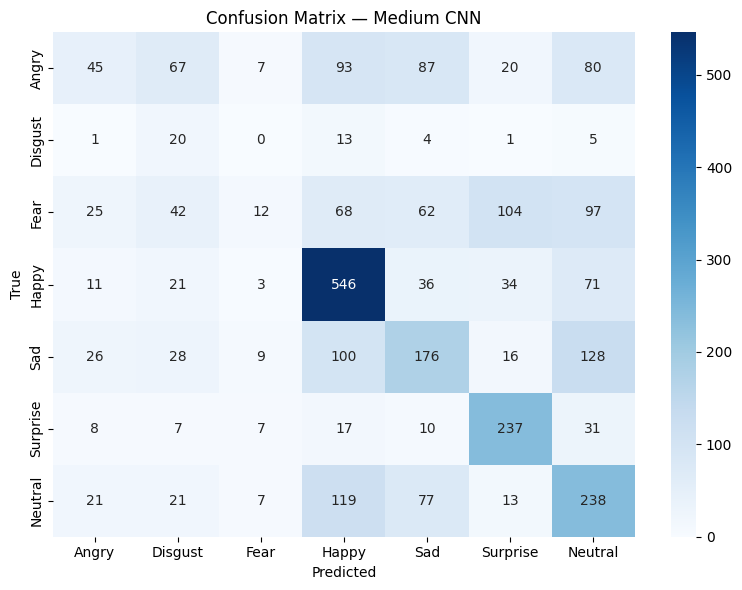

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_labels,
            yticklabels=emotion_labels, cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Medium CNN')
plt.tight_layout()
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.show()

In [22]:
wandb.summary['best_val_acc'] = best_val_acc
wandb.summary['test_acc']     = test_acc
wandb.finish()

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_acc_angry,▁
test_acc_disgust,▁
test_acc_fear,▁
test_acc_happy,▁
test_acc_neutral,▁
test_acc_sad,▁
+6,...
